## 1. Imports and setup

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Global matplotlib settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['savefig.bbox'] = 'tight'

sns.set_style("whitegrid")

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "promise_final.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Reading: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Loaded data: {len(df)} requirements, {df.shape[1]} columns")
df.head()

Reading: /Users/luciano/Developer/requirements-analyzer/data/processed/promise_final.csv
Loaded data: 3677 requirements, 6 columns


,project_id,text,class,ambiguity,weak_verb,incompleteness
0,1,The system shall refresh the display every 60 ...,PE,0,0,0
1,1,The system shall provide a history report of c...,F,0,0,0
2,1,The system shall provide charts for the Activi...,F,0,0,0
3,1,The system shall offer the ability to pause an...,F,0,0,0
4,1,The system shall display the local and exercis...,F,0,0,0


## 2. Summary tabel

In [20]:
n_total = len(df)
n_projects = df["project_id"].nunique()
n_classes = df["class"].nunique()
n_fr = (df["class"] == "F").sum()
n_nfr = n_total - n_fr

print("=" * 60)
print("PROMISE+ DATASET SUMMARY")
print("=" * 60)
print(f"Total requirements:           {n_total:>6}")
print(f"Unique projects:           {n_projects:>6}")
print(f"Distinct classes:          {n_classes:>6}")
print(f"  Functional (FR):       {n_fr:>6} ({n_fr/n_total*100:.1f}%)")
print(f"  Non-functional (NFR):  {n_nfr:>6} ({n_nfr/n_total*100:.1f}%)")
print()
print("Detected smells:")
for col in ["ambiguity", "weak_verb", "incompleteness"]:
    n = df[col].sum()
    print(f"  {col:18}{n:>6} ({n/n_total*100:.1f}%)")
print()
n_clean = (df[["ambiguity","weak_verb","incompleteness"]].sum(axis=1) == 0).sum()
print(f"Requirements without smells:      {n_clean:>6} ({n_clean/n_total*100:.1f}%)")

PROMISE+ DATASET SUMMARY
Total requirements:             3677
Unique projects:               88
Distinct classes:              12
  Functional (FR):         2258 (61.4%)
  Non-functional (NFR):    1419 (38.6%)

Detected smells:
  ambiguity            707 (19.2%)
  weak_verb            595 (16.2%)
  incompleteness        25 (0.7%)

Requirements without smells:        2533 (68.9%)


## 3. Class distribution

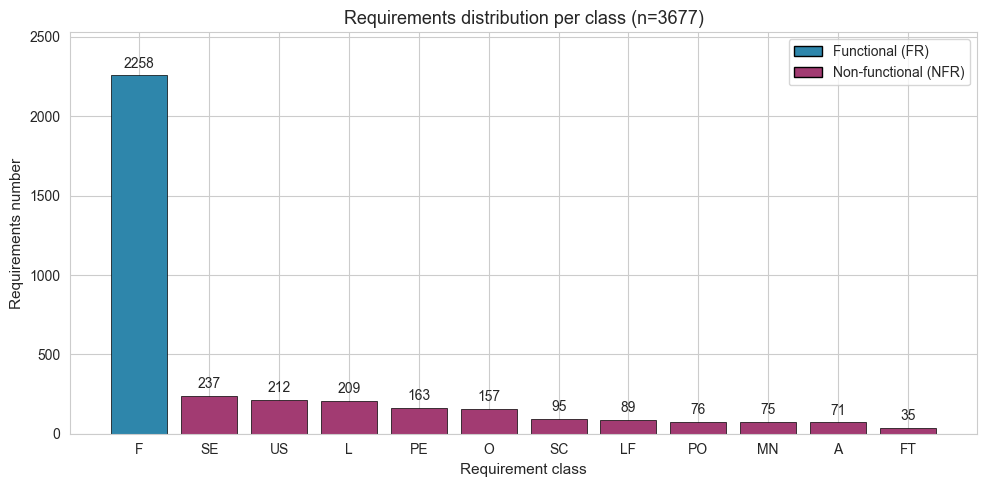


Observations:
  - Dominant F class: 2258 (61.4%)
  - Minor class: FT with only 35 requirements
  - Max/min report: 64.5×


In [21]:
# Descending order
fig, ax = plt.subplots(figsize=(10, 5))

class_counts = df["class"].value_counts()

colors = ['#2E86AB' if c == 'F' else '#A23B72' for c in class_counts.index]

bars = ax.bar(class_counts.index, class_counts.values, color=colors,
              edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Requirement class")
ax.set_ylabel("Requirements number")
ax.set_title("Requirements distribution per class (n=3677)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', edgecolor='black', label='Functional (FR)'),
    Patch(facecolor='#A23B72', edgecolor='black', label='Non-functional (NFR)'),
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_ylim(0, class_counts.max() * 1.12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_01_class_distribution.pdf")
plt.show()

print(f"\nObservations:")
print(f"  - Dominant F class: {class_counts['F']} ({class_counts['F']/n_total*100:.1f}%)")
print(f"  - Minor class: {class_counts.index[-1]} with only {class_counts.iloc[-1]} requirements")
print(f"  - Max/min report: {class_counts.max() / class_counts.min():.1f}×")

## 4. Requirements length distribution

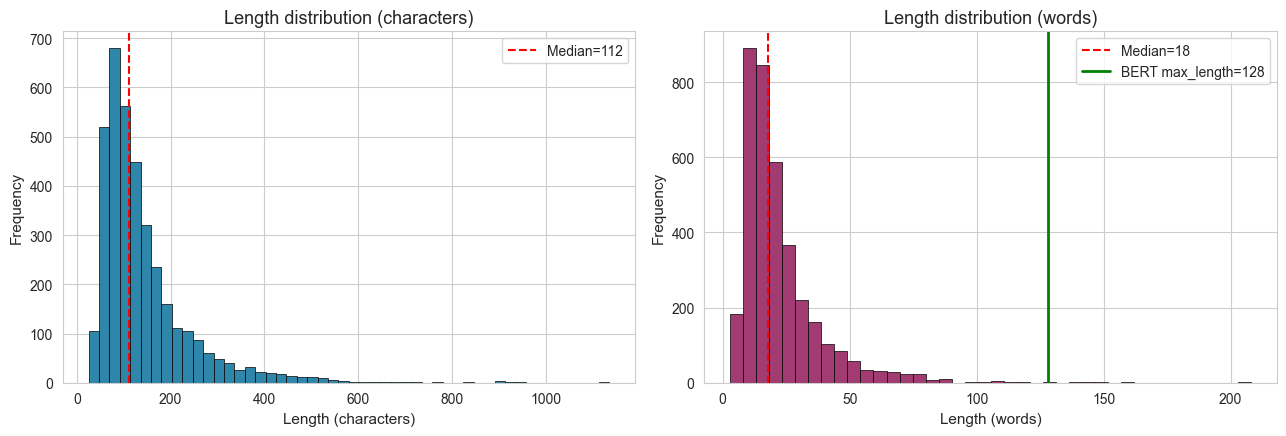


Observations:
  - Average length: 142 chars / 23 words
  - Median: 112 chars / 18 words
  - Max: 1135 chars / 208 words
  - Requirements > 128 words (will be truncated by BERT): 0.2%


In [22]:
df["text_length_chars"] = df["text"].str.len()
df["text_length_words"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Character histogram
axes[0].hist(df["text_length_chars"], bins=50, color='#2E86AB',
             edgecolor='black', linewidth=0.5)
axes[0].axvline(df["text_length_chars"].median(), color='red',
                linestyle='--', linewidth=1.5, label=f'Median={df["text_length_chars"].median():.0f}')
axes[0].set_xlabel("Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Length distribution (characters)")
axes[0].legend()

# Words histogram
axes[1].hist(df["text_length_words"], bins=40, color='#A23B72',
             edgecolor='black', linewidth=0.5)
axes[1].axvline(df["text_length_words"].median(), color='red',
                linestyle='--', linewidth=1.5, label=f'Median={df["text_length_words"].median():.0f}')
axes[1].axvline(128, color='green', linestyle='-', linewidth=2,
                label='BERT max_length=128')
axes[1].set_xlabel("Length (words)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Length distribution (words)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_02_length_distribution.pdf")
plt.show()

# Percentage of truncated requirements
pct_truncated = (df["text_length_words"] > 128).sum() / len(df) * 100
print(f"\nObservations:")
print(f"  - Average length: {df['text_length_chars'].mean():.0f} chars / {df['text_length_words'].mean():.0f} words")
print(f"  - Median: {df['text_length_chars'].median():.0f} chars / {df['text_length_words'].median():.0f} words")
print(f"  - Max: {df['text_length_chars'].max()} chars / {df['text_length_words'].max()} words")
print(f"  - Requirements > 128 words (will be truncated by BERT): {pct_truncated:.1f}%")

## 5. Smells prevalence

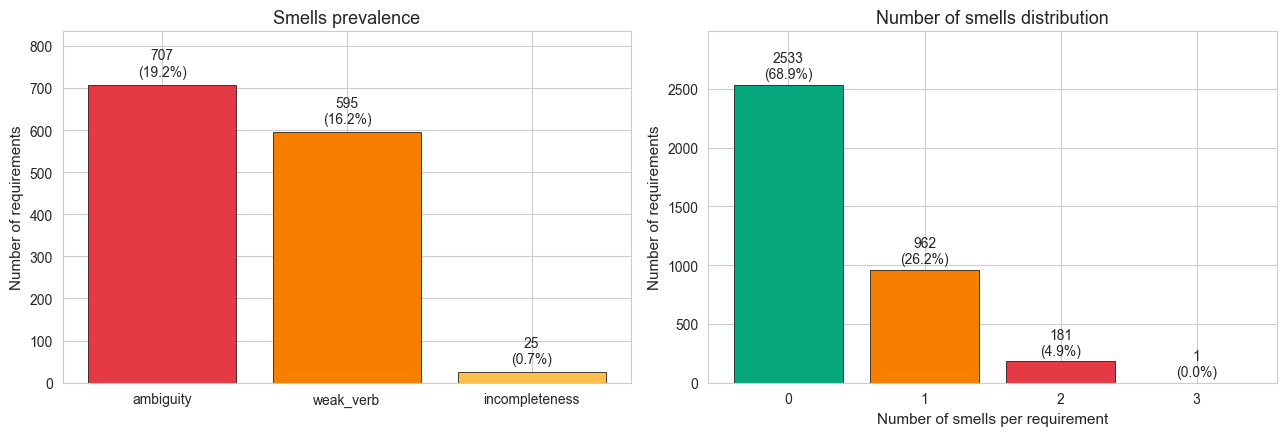

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Prevalence bar chart
smell_cols = ["ambiguity", "weak_verb", "incompleteness"]
smell_counts = [df[c].sum() for c in smell_cols]
smell_pct = [c/n_total*100 for c in smell_counts]

bars = axes[0].bar(smell_cols, smell_counts,
                    color=['#E63946', '#F77F00', '#FCBF49'],
                    edgecolor='black', linewidth=0.5)
for bar, count, pct in zip(bars, smell_counts, smell_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                  f"{count}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

axes[0].set_ylabel("Number of requirements")
axes[0].set_title("Smells prevalence")
axes[0].set_ylim(0, max(smell_counts) * 1.18)

n_smells = df[smell_cols].sum(axis=1)
smell_dist = n_smells.value_counts().sort_index()
colors_dist = ['#06A77D', '#F77F00', '#E63946', '#660708']

bars2 = axes[1].bar(smell_dist.index.astype(str), smell_dist.values,
                     color=colors_dist[:len(smell_dist)],
                     edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, smell_dist.values):
    pct = val/n_total*100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                  f"{val}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

axes[1].set_xlabel("Number of smells per requirement")
axes[1].set_ylabel("Number of requirements")
axes[1].set_title("Number of smells distribution")
axes[1].set_ylim(0, smell_dist.max() * 1.18)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_03_smell_prevalence.pdf")
plt.show()

## 6. Smells per class ( Heatmap )

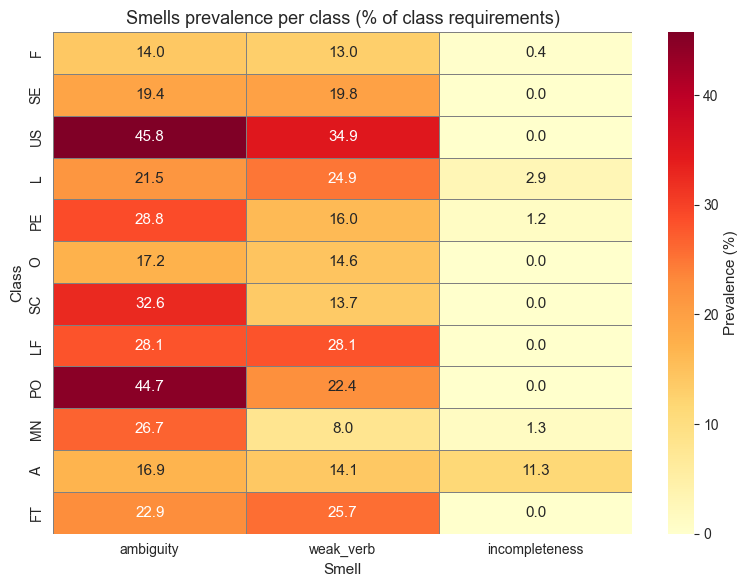


Key observations:
  - US has the highest prevalence of ambiguity: 45.8%
  - US has the highest prevalence of weak_verb: 34.9%
  - A has the highest prevalence of incompleteness: 11.3%


In [24]:
class_smell = df.groupby("class")[smell_cols].mean() * 100

# Descending order on number of requirements
class_order = df["class"].value_counts().index.tolist()
class_smell = class_smell.loc[class_order]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(class_smell, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={'label': 'Prevalence (%)'},
            linewidths=0.5, linecolor='gray', ax=ax)
ax.set_xlabel("Smell")
ax.set_ylabel("Class")
ax.set_title("Smells prevalence per class (% of class requirements)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_04_smell_per_class.pdf")
plt.show()

print("\nKey observations:")
for smell in smell_cols:
    top_class = class_smell[smell].idxmax()
    top_val = class_smell[smell].max()
    print(f"  - {top_class} has the highest prevalence of {smell}: {top_val:.1f}%")

## 7. Requirements per project

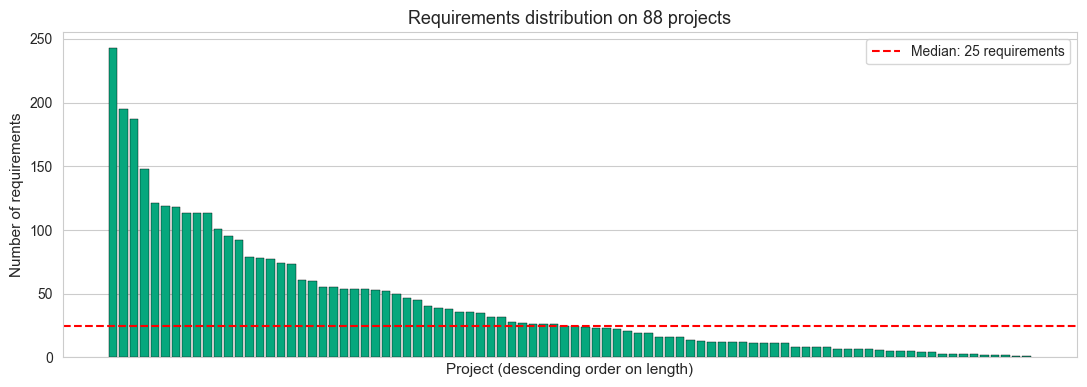


Observations:
  - Biggest project: 243 requirements
  - Smallest project: 1 requirements
  - Median: 25 requirements


In [25]:
fig, ax = plt.subplots(figsize=(11, 4))

reqs_per_proj = df["project_id"].value_counts().sort_values(ascending=False)

ax.bar(range(len(reqs_per_proj)), reqs_per_proj.values,
       color='#06A77D', edgecolor='black', linewidth=0.3)
ax.set_xlabel("Project (descending order on length)")
ax.set_ylabel("Number of requirements")
ax.set_title(f"Requirements distribution on {n_projects} projects")

# Median line
ax.axhline(reqs_per_proj.median(), color='red', linestyle='--',
            label=f'Median: {reqs_per_proj.median():.0f} requirements')
ax.legend()

ax.set_xticks([])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_05_reqs_per_project.pdf")
plt.show()

print(f"\nObservations:")
print(f"  - Biggest project: {reqs_per_proj.max()} requirements")
print(f"  - Smallest project: {reqs_per_proj.min()} requirements")
print(f"  - Median: {reqs_per_proj.median():.0f} requirements")